In [ ]:
import zipfile
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

--2025-04-03 10:33:20--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.188.207, 192.178.163.207, 173.194.202.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.188.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M   163MB/s    in 0.6s    

2025-04-03 10:33:20 (163 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



In [ ]:
#1
#!unzip /content/pizza_steak.zip

In [ ]:
#2
# zip_ref = zipfile.ZipFile('/content/pizza_steak.zip','r')
# zip_ref.extractall()
# zip_ref.close()

In [ ]:
with zipfile.ZipFile('/content/pizza_steak.zip','r') as zip_ref:
    zip_ref.extractall()

In [ ]:
!ls /content/pizza_steak/test

pizza  steak


In [ ]:
import os

for dirpath,dirnames,filenames in os.walk('/content/pizza_steak'):
    print(f"there are{len(dirnames)}directories and {len(filenames)} images in '{dirpath}'.")

there are2directories and 0 images in '/content/pizza_steak'.
there are2directories and 0 images in '/content/pizza_steak/train'.
there are0directories and 750 images in '/content/pizza_steak/train/pizza'.
there are0directories and 750 images in '/content/pizza_steak/train/steak'.
there are2directories and 0 images in '/content/pizza_steak/test'.
there are0directories and 250 images in '/content/pizza_steak/test/pizza'.
there are0directories and 250 images in '/content/pizza_steak/test/steak'.


In [ ]:
num_steak_images_train = len(os.listdir('/content/pizza_steak/train/pizza'))
num_steak_images_train

750

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import pathlib
import os # Make sure os is imported

def view_random_image(target_dir,target_class):
    # Convert target_dir to a pathlib.Path object
    target_dir = pathlib.Path(target_dir)
    target_folder = target_dir / target_class
    random_image = random.sample(os.listdir(target_folder),1)
    # Build the correct file path by joining target_folder and the random image filename
    img_path = os.path.join(target_folder, random_image[0])
    # Pass the image path to imread()
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")
    print(f"image shape :{img.shape}")

image shape :(307, 512, 3)


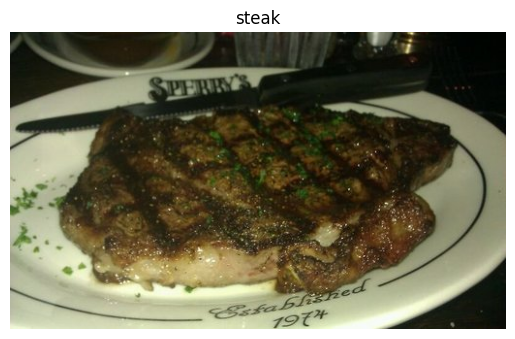

In [ ]:
view_random_image(target_dir='/content/pizza_steak/train/',target_class='steak')

In [ ]:
import tensorflow as tf
IMG_SIZE = (224,224)

train_dir = '/content/pizza_steak/train'
test_dir = '/content/pizza_steak/test'

train_data = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                 label_mode = 'binary',
                                                                 image_size = IMG_SIZE,
                                                                 shuffle = True,
                                                                 crop_to_aspect_ratio = True,
                                                                 batch_size = 32)
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                 label_mode = 'binary',
                                                                 image_size = IMG_SIZE,
                                                                 shuffle = True,
                                                                 crop_to_aspect_ratio = True,
                                                                 batch_size = 32)

Found 1500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[224,224,3]),
    tf.keras.layers.Rescaling(1/255.),
    tf.keras.layers.Conv2D(filters = 64,kernel_size=7,padding = 'same',activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.MaxPool2D(pool_size = 2),
    tf.keras.layers.Conv2D(filters = 128,kernel_size=3,padding = 'same',activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.Conv2D(filters = 128,kernel_size=3,padding = 'same',activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.MaxPool2D(pool_size = 2),
    tf.keras.layers.Conv2D(filters = 256,kernel_size=3,padding = 'same' ,activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.Conv2D(filters = 256 ,kernel_size=3,padding = 'same',activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.MaxPool2D(pool_size = 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units = 128,activation='relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units = 128,activation='relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units = 1,activation='sigmoid')
])

In [ ]:
model.compile(loss = 'binary_crossentropy',
              optimizer = tf.keras.optimizers.SGD(learning_rate=0.001,momentum=0.9),
              metrics = ['accuracy'])

model.fit(train_data,validation_data=test_data,epochs=5)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 299ms/step - accuracy: 0.5214 - loss: 0.9192 - val_accuracy: 0.6960 - val_loss: 0.6221
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - accuracy: 0.6176 - loss: 0.6430 - val_accuracy: 0.7840 - val_loss: 0.5065
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 233ms/step - accuracy: 0.7232 - loss: 0.5718 - val_accuracy: 0.8220 - val_loss: 0.4777
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 233ms/step - accuracy: 0.7534 - loss: 0.5193 - val_accuracy: 0.7960 - val_loss: 0.4388
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 228ms/step - accuracy: 0.7405 - loss: 0.5101 - val_accuracy: 0.7900 - val_loss: 0.4584


In [ ]:
model.evaluate(train_data)

47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 197ms/step - accuracy: 0.4867 - loss: nan


[nan, 0.5]

In [ ]:
model.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4891 - loss: nan


[nan, 0.5]

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomHeight(0.1),
    tf.keras.layers.RandomWidth(0.1)
])

In [ ]:
class_names=train_data.class_names

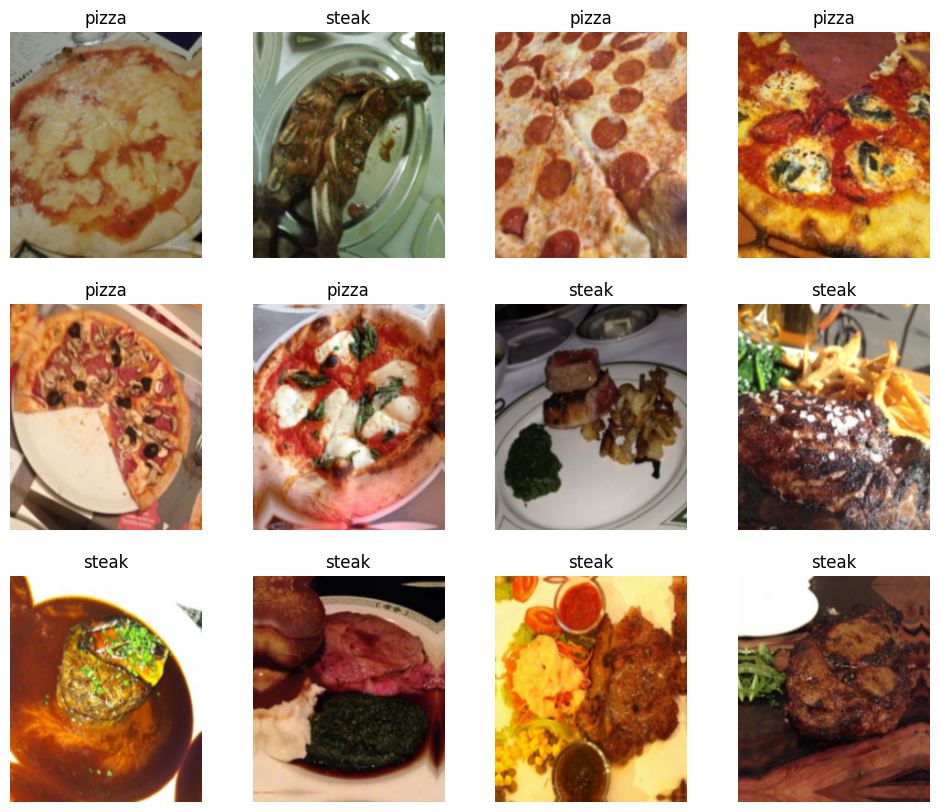

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12,10))
for images,labels in train_data.take(1):
    augmented_images = data_augmentation(images)
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(augmented_images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i].numpy().astype('int8')[0]])
        plt.axis('off')

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[224,224,3]),
    data_augmentation,
    tf.keras.layers.Rescaling(1/255.),
    tf.keras.layers.Resizing(224,224),
    tf.keras.layers.Conv2D(filters = 64,kernel_size=7,padding = 'same',activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.MaxPool2D(pool_size = 2),
    tf.keras.layers.Conv2D(filters = 128,kernel_size=3,padding = 'same',activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.Conv2D(filters = 128,kernel_size=3,padding = 'same',activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.MaxPool2D(pool_size = 2),
    tf.keras.layers.Conv2D(filters = 256,kernel_size=3,padding = 'same' ,activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.Conv2D(filters = 256 ,kernel_size=3,padding = 'same',activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.MaxPool2D(pool_size = 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units = 128,activation='relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units = 128,activation='relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units = 1,activation='sigmoid')
])

In [ ]:
model.compile(loss = 'binary_crossentropy',
              optimizer = tf.keras.optimizers.SGD(learning_rate = 0.0003,momentum = 0.9),
              metrics=['accuracy'])

In [ ]:
model.fit(train_data,epochs=5, validation_data=test_data)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 278ms/step - accuracy: 0.8309 - loss: 0.3898 - val_accuracy: 0.8520 - val_loss: 0.3090
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 232ms/step - accuracy: 0.8323 - loss: 0.3903 - val_accuracy: 0.8660 - val_loss: 0.2998
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 233ms/step - accuracy: 0.8312 - loss: 0.3752 - val_accuracy: 0.8480 - val_loss: 0.3000
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 226ms/step - accuracy: 0.8481 - loss: 0.3607 - val_accuracy: 0.8640 - val_loss: 0.2893
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 230ms/step - accuracy: 0.8561 - loss: 0.3438 - val_accuracy: 0.8800 - val_loss: 0.2897


In [ ]:
base_model = tf.keras.applications.ResNet50(include_top =False)

avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)

output = tf.keras.layers.Dense(units = 1,activation = 'sigmoid')(avg)

model = tf.keras.Model(inputs = base_model.input,outputs = output)



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.training =False

In [ ]:
initial_learning_rate = 0.01
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps = 47,
    decay_rate = 0.96
)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 3,restore_best_weights = True)

model.compile(
    loss = 'binary_crossentropy',
    optimizer =tf.keras.optimizers.SGD(learning_rate = lr_schedule,momentum = 0.9),
    metrics = ['accuracy']
)

model.fit(train_data,epochs = 15,
          validation_data = test_data,
          callbacks = early_stopping)

Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 81s 902ms/step - accuracy: 0.8013 - loss: 0.4003 - val_accuracy: 0.8780 - val_loss: 0.9759
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 304ms/step - accuracy: 0.9572 - loss: 0.1201 - val_accuracy: 0.9680 - val_loss: 0.1193
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 308ms/step - accuracy: 0.9808 - loss: 0.0564 - val_accuracy: 0.9640 - val_loss: 0.1197
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 305ms/step - accuracy: 0.9924 - loss: 0.0230 - val_accuracy: 0.9820 - val_loss: 0.0525
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 312ms/step - accuracy: 0.9978 - loss: 0.0050 - val_accuracy: 0.9540 - val_loss: 0.1464
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 299ms/step - accuracy: 0.9998 - loss: 0.0028 - val_accuracy: 0.9760 - val_loss: 0.0669
Epoch 7/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 330ms/step - accuracy: 1.0000 - loss: 7.9726e-04 - val_accuracy: 0.9840 - val_loss: 0.0545


In [ ]:
inputs = tf.keras.layers.Input(shape = (224,224,3))

x=data_augmentation(inputs)

x = tf.keras.applications.resnet50.preprocess_input(x)

base_model = tf.keras.applications.ResNet50(include_top = False)(x)

avg = tf.keras.layers.GlobalAveragePooling2D()(base_model)

output = tf.keras.layers.Dense(units = 1,activation = 'sigmoid')(avg)

model = tf.keras.Model(inputs = inputs,outputs = output)

In [ ]:
base_model.training = False

In [ ]:
initial_learning_rate = 0.01
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps = 47,
    decay_rate = 0.96
)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 3,restore_best_weights = True)

model.compile(
    loss = 'binary_crossentropy',
    optimizer =tf.keras.optimizers.SGD(learning_rate = lr_schedule,momentum = 0.9),
    metrics = ['accuracy']
)

model.fit(train_data,epochs = 15,
          validation_data = test_data,
          callbacks = early_stopping)

Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.8229 - loss: 0.3281 - val_accuracy: 0.9080 - val_loss: 0.2792
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9236 - loss: 0.1916 - val_accuracy: 0.8220 - val_loss: 1.9283
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9568 - loss: 0.1127 - val_accuracy: 0.7360 - val_loss: 1.6444
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 70s 894ms/step - accuracy: 0.9700 - loss: 0.0695 - val_accuracy: 0.9620 - val_loss: 0.1517
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 84s 933ms/step - accuracy: 0.9805 - loss: 0.0573 - val_accuracy: 0.9680 - val_loss: 0.1546
Epoch 6/15
